# 01 — Data Cleaning and Exploratory Data Analysis

**Purpose.** Load the Complete Journey grocery retail dataset, assess data quality (missing values, duplicates, outliers), explore the main behavioral variables, and save a cleaned transaction table for feature engineering in notebook 02.

**Dataset.** The Complete Journey data from 84.51° contains household-level grocery transactions over one year, including purchase week, product category, quantity, sales value, discounts, and coupon usage (84.51°, n.d.). It is accessed through the open-source `completejourney` R package data files (Boehmke, 2020). This notebook uses the published transaction sample together with the full product table.

**Outputs:** `data/processed/transactions_clean.parquet`

## 1. Setup

In [1]:
# Make the src/ package importable when running from the notebooks/ folder.
# Alternative: run 'pip install -e .' once from the repo root.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.append(str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 3.0.3 | numpy 2.4.6


## 2. Load the Dataset

The loader downloads the transaction sample and product tables, merges them on `product_id`, and normalizes the result into a consistent schema: household identifier, purchase week, product category, quantity, sales value, combined discount value, and a coupon-use indicator.

In [2]:
from campaign_strategist.data import load_completejourney_sample

df, source = load_completejourney_sample()

print('Data source:', source)
print('Shape:', df.shape)

df.head()

Data source: completejourney public sample
Shape: (75000, 7)


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
0,2261,5,lunchmeat,1.0,3.86,0.43,0
1,2131,10,baked bread/buns/rolls,1.0,1.59,0.90,0
2,511,13,warehouse snacks,1.0,1.00,0.69,0
3,400,8,beef,2.0,11.87,2.90,0
4,918,10,soft drinks,1.0,1.29,0.00,0


In [3]:
# ------------------------------------------------------------
# Examine the overall structure of the dataset
# ------------------------------------------------------------

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Columns")
print("=" * 60)
print(df.columns.tolist())

print("\n")

print("=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

Dataset Shape
(75000, 7)


Columns
['household_id', 'week', 'product_category', 'quantity', 'sales_value', 'discount_value', 'used_coupon']


Data Types
household_id            str
week                  int64
product_category        str
quantity            float64
sales_value         float64
discount_value      float64
used_coupon           int64
dtype: object


## 3. Data Quality Assessment

This section evaluates the completeness and consistency of the dataset by checking missing values, duplicate records, and extreme values. Understanding data quality early determines which preprocessing steps are required before model development.

### 3.1 Missing Values

In [4]:
# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

missing_values = df.isnull().sum()

print("=" * 60)
print("Missing Values by Column")
print("=" * 60)

print(missing_values)

print("\n")

print("=" * 60)
print("Percentage Missing")
print("=" * 60)

print((missing_values / len(df) * 100).round(2))

Missing Values by Column
household_id        0
week                0
product_category    0
quantity            0
sales_value         0
discount_value      0
used_coupon         0
dtype: int64


Percentage Missing
household_id        0.0
week                0.0
product_category    0.0
quantity            0.0
sales_value         0.0
discount_value      0.0
used_coupon         0.0
dtype: float64


### 3.2 Duplicate Records

Duplicate transactions can bias summary statistics and model training. Duplicates do not always indicate data quality problems, so the duplicated observations are inspected to determine whether they are true duplicates or legitimate transactions with identical values.

In [5]:
# ------------------------------------------------------------
# Check for duplicate records
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("Duplicate Record Assessment")
print("=" * 60)

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count == 0:
    print("No duplicate records were found.")
else:
    print(f"{duplicate_count} duplicate records were identified.")

Duplicate Record Assessment
Duplicate rows: 649
649 duplicate records were identified.


In [6]:
# ------------------------------------------------------------
# Inspect duplicate records
# ------------------------------------------------------------

duplicates = df[df.duplicated(keep=False)].sort_values(
    by=["household_id", "week"]
)

print("=" * 60)
print("Sample Duplicate Records")
print("=" * 60)

duplicates.head(20)

Sample Duplicate Records


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
13547,1002,15,frzn meat/meat dinners,1.0,2.00,1.19,0
68339,1002,15,frzn meat/meat dinners,1.0,2.00,1.19,0
31505,1010,44,rice cakes,1.0,1.00,0.99,0
37887,1010,44,rice cakes,1.0,1.00,0.99,0
12570,1013,9,frzn meat/meat dinners,1.0,7.49,0.00,0
66114,1013,9,frzn meat/meat dinners,1.0,7.49,0.00,0
42283,1014,37,vegetables - all others,1.0,2.49,0.00,0
58484,1014,37,vegetables - all others,1.0,2.49,0.00,0
50200,1020,27,convenient brkfst/whlsm snacks,1.0,2.79,0.90,0
54304,1020,27,convenient brkfst/whlsm snacks,1.0,2.79,0.90,0


In [7]:
# ------------------------------------------------------------
# Dataset size before and after duplicate removal
# ------------------------------------------------------------

print("=" * 60)
print("Duplicate Summary")
print("=" * 60)

print(f"Rows before removing duplicates : {len(df):,}")

df_no_duplicates = df.drop_duplicates()

print(f"Rows after removing duplicates  : {len(df_no_duplicates):,}")

print(f"Duplicate rows removed          : {len(df) - len(df_no_duplicates):,}")

print(f"Percent duplicates              : {((len(df) - len(df_no_duplicates)) / len(df) * 100):.2f}%")

Duplicate Summary
Rows before removing duplicates : 75,000
Rows after removing duplicates  : 74,351
Duplicate rows removed          : 649
Percent duplicates              : 0.87%


### 3.3 Duplicate Origin Investigation

To find where the duplicates come from, the original source tables are checked before normalization, and the original transaction variables are compared with the normalized schema.

In [8]:
from campaign_strategist.data import _read_rda

# Load the original source tables before normalization
raw_transactions = _read_rda('transactions_sample')
raw_products = _read_rda('products')

raw_transactions.columns = [str(col).lower() for col in raw_transactions.columns]
raw_products.columns = [str(col).lower() for col in raw_products.columns]

print('=' * 60)
print('Source Table Assessment')
print('=' * 60)
print(f'Raw transaction rows             : {len(raw_transactions):,}')
print(f'Exact duplicate transaction rows : {raw_transactions.duplicated().sum():,}')
print(f'Raw product rows                 : {len(raw_products):,}')
print(f'Duplicate product IDs            : {raw_products["product_id"].duplicated().sum():,}')

Source Table Assessment
Raw transaction rows             : 75,000
Exact duplicate transaction rows : 0
Raw product rows                 : 92,331
Duplicate product IDs            : 0


In [9]:
print("=" * 60)
print("Original Transaction Columns")
print("=" * 60)

print(raw_transactions.columns.tolist())

print("\n")

print("=" * 60)
print("Normalized Dataset Columns")
print("=" * 60)

print(df.columns.tolist())

Original Transaction Columns
['household_id', 'store_id', 'basket_id', 'product_id', 'quantity', 'sales_value', 'retail_disc', 'coupon_disc', 'coupon_match_disc', 'week', 'transaction_timestamp']


Normalized Dataset Columns
['household_id', 'week', 'product_category', 'quantity', 'sales_value', 'discount_value', 'used_coupon']


### 3.4 Data Quality Summary

The dataset contains no missing values. A small number of duplicate records were identified, and the investigation shows they are introduced during normalization: several transaction-specific fields (such as store, basket, and time identifiers) are removed to simplify the dataset, which makes some distinct source transactions identical. Because these rows represent real purchases, the duplicates are removed only once, in the final cleaning step of this notebook, and the decision is documented for the report.

## 4. Descriptive Statistics

This section summarizes the numerical variables in the processed dataset. These statistics provide an initial understanding of customer purchasing behavior and help identify patterns that may influence feature engineering and model development.

In [10]:
# ------------------------------------------------------------
# Descriptive statistics for numerical variables
# ------------------------------------------------------------

print("=" * 60)
print("Numerical Summary Statistics")
print("=" * 60)

df.describe()

Numerical Summary Statistics


,week,quantity,sales_value,discount_value,used_coupon
count,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,27.360787,103.795920,3.119137,0.557063,0.015133
std,15.124029,1173.177298,4.023211,1.277609,0.122084
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,1.000000,1.290000,0.000000,0.000000
50%,27.000000,1.000000,2.000000,0.060000,0.000000
75%,41.000000,1.000000,3.490000,0.690000,0.000000
max,53.000000,32623.000000,100.000000,90.000000,1.000000


### Initial Observations

Most purchases consist of a single item with relatively low sales values, and only a small share of transactions involve coupon use. The summary also shows extreme values, particularly for purchase quantity, which are investigated next.

### 4.1 Quantity Outlier Investigation

In [11]:
# ------------------------------------------------------------
# Investigate unusually large purchase quantities
# ------------------------------------------------------------

print("=" * 60)
print("Top 10 Largest Purchase Quantities")
print("=" * 60)

df.nlargest(10, "quantity")

Top 10 Largest Purchase Quantities


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
54305,2133,37,coupon/misc items,32623.0,75.00,3.26,0
48962,1959,24,fuel,30080.0,86.01,0.00,0
12830,2404,40,coupon/misc items,29945.0,61.96,0.89,0
59241,2416,36,coupon/misc items,28469.0,63.46,2.84,0
2950,2190,51,coupon/misc items,26648.0,57.00,2.66,0
49055,1765,34,coupon/misc items,26547.0,65.01,2.66,0
388,1959,33,coupon/misc items,26325.0,75.00,3.95,0
44208,1008,49,coupon/misc items,25790.0,58.00,0.01,0
23361,2354,6,coupon/misc items,24748.0,56.65,0.01,0
25856,1764,28,coupon/misc items,24583.0,68.81,2.46,0


### Interpretation

The largest quantity values are associated mainly with the **coupon/misc items** and **fuel** categories rather than standard grocery purchases. These rows represent specialized transaction types (fuel volume and coupon bookkeeping entries), not item counts, so treating them as product purchases would distort the journey features. Both categories are excluded from the modeling dataset in Section 6.

## 5. Exploratory Data Analysis

The following analyses examine the behavioral variables that the project's activation-style recommendations depend on: what customers buy, how much they spend, and how often they use coupons.

### 5.1 Product Category Distribution

Category frequency shows which product areas dominate purchasing behavior and informs the category share features used by the models.

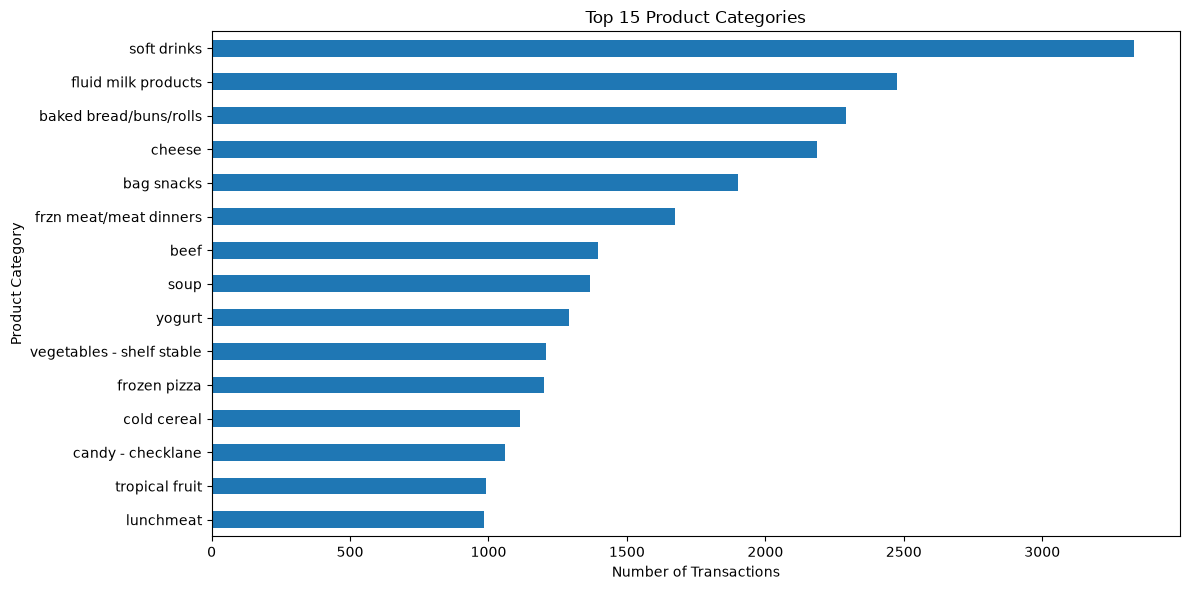

In [12]:
# ------------------------------------------------------------
# Top product categories
# ------------------------------------------------------------

category_counts = (
    df["product_category"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

category_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Product Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### 5.2 Coupon Usage

Coupon usage is expected to be an important signal for the price-led coupon activation style.

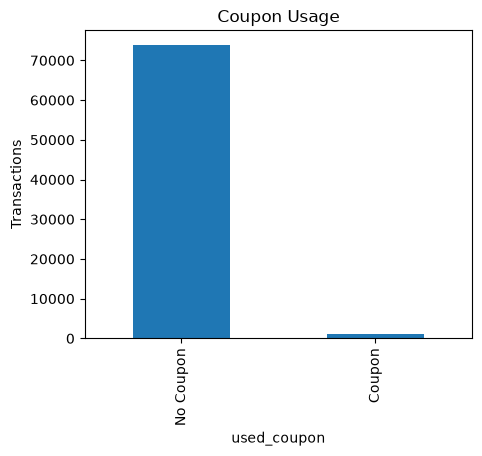

In [13]:
coupon_counts = df["used_coupon"].value_counts()

plt.figure(figsize=(5,4))

coupon_counts.plot(kind="bar")

plt.xticks([0,1],["No Coupon","Coupon"])

plt.title("Coupon Usage")

plt.ylabel("Transactions")

plt.show()

### 5.3 Sales Value Distribution

The spend distribution reveals typical basket values and the skewness that motivates log-scaling of spend features.

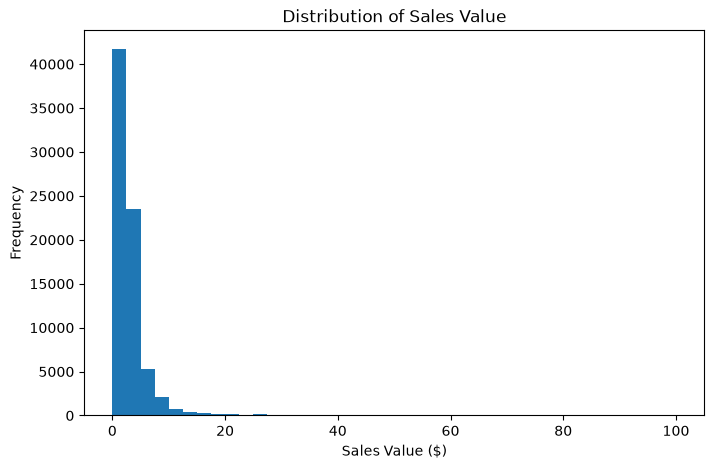

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["sales_value"], bins=40)

plt.title("Distribution of Sales Value")

plt.xlabel("Sales Value ($)")

plt.ylabel("Frequency")

plt.show()

### 5.4 Correlation Analysis

Linear relationships between numerical variables are checked to anticipate redundancy among candidate features.

In [15]:
numeric_df = df.select_dtypes(include=["int32","int64","float64"])

correlation = numeric_df.corr()

print(correlation)

                    week  quantity  sales_value  discount_value  used_coupon
week            1.000000  0.002675     0.015667        0.006375     0.011493
quantity        0.002675  1.000000     0.637188        0.033953    -0.010839
sales_value     0.015667  0.637188     1.000000        0.246007     0.014003
discount_value  0.006375  0.033953     0.246007        1.000000     0.169626
used_coupon     0.011493 -0.010839     0.014003        0.169626     1.000000


## 6. Save the Cleaned Dataset

Two cleaning decisions from the analysis above are applied before saving:

1. **Duplicate removal** (Section 3): duplicates introduced by normalization are dropped.
2. **Outlier category exclusion** (Section 4.1): the *coupon/misc items* and *fuel* categories are excluded because they are specialized transaction types, not grocery purchases, and their extreme quantity values would distort the weekly journey features.

The cleaned transaction table is saved for feature engineering in notebook 02.

In [16]:
from campaign_strategist.config import PROCESSED_DATA_DIR

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_CATEGORIES = ['coupon/misc items', 'fuel']

df_clean = df.drop_duplicates().reset_index(drop=True)
before = len(df_clean)
df_clean = df_clean[~df_clean['product_category'].isin(EXCLUDED_CATEGORIES)].reset_index(drop=True)
print(f'Removed {before - len(df_clean):,} rows from excluded categories: {EXCLUDED_CATEGORIES}')

out_path = PROCESSED_DATA_DIR / 'transactions_clean.parquet'
df_clean.to_parquet(out_path, index=False)
print(f'Saved {len(df_clean):,} rows to {out_path}')

Removed 900 rows from excluded categories: ['coupon/misc items', 'fuel']


Saved 73,451 rows to /Users/matthashemi/Documents/Personal/University/MS-AAI-Courses/11-AAI-590/agentic-campaign-strategist/data/processed/transactions_clean.parquet


## 7. Summary of Findings

The exploratory analysis shows that the dataset is complete and suitable for machine learning. No missing values were identified, and the small number of duplicate records was traced to the normalization process rather than the original retail data; these rows were removed in the final cleaning step, together with the *coupon/misc items* and *fuel* categories whose extreme quantity values represent specialized transaction types rather than grocery purchases. Product category, sales value, discount value, coupon usage, and transaction week appear to be informative signals of customer purchasing behavior and likely marketing response. These observations guide the feature engineering and labeling work in notebook 02.

## References

84.51°. (n.d.). *The Complete Journey* [Data set]. https://www.8451.com/area51

Boehmke, B. (2020). *completejourney: Retail shopping transactions for 2,469 households* [R package]. https://github.com/bradleyboehmke/completejourney

Harris, C. R., et al. (2020). Array programming with NumPy. *Nature, 585*, 357–362.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61.